
O_R1s(r) =
+27.3434 * exp(-11.2970 r)
+15.8117 * exp(-6.5966 r)
-15.1029 * r^2 * exp(-20.5019 r)
+67.9178 * r * exp(-9.5546 r)
+0.0443 * r * exp(-3.2482 r)
+0.0017 * r * exp(-2.1608 r)
+0.0005 * r * exp(-1.6411 r)

O_R2s(r) =
-4.8878 * exp(-11.2970 r)
+14.6786 * exp(-6.5966 r)
-4.5243 * r^2 * exp(-20.5019 r)
-23.6222 * r * exp(-9.5546 r)
-8.1220 * r * exp(-3.2482 r)
-4.0626 * r * exp(-2.1608 r)
-0.9060 * r * exp(-1.6411 r)

O_R2p(r) =
+1.8779 * r * exp(-9.6471 r)
+5.7116 * r * exp(-4.3323 r)
+4.7647 * r * exp(-2.7502 r)
+1.8564 * r * exp(-1.7525 r)
+0.4650 * r * exp(-1.2473 r)


/tmp/ipykernel_5221/711076379.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 1.0000005235271137
Norm 2s = 0.9999994939781228
Norm 2p = 0.9999997641492973
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       1.133340e-01       5.789582e-01       3.475201e-01   
1       0.05       1.133181e-01       5.769933e-01       3.475144e-01   
2       0.10       1.132703e-01       5.711472e-01       3.474640e-01   
3       0.15       1.131907e-01       5.615640e-01       3.472735e-01   
4       0.20       1.130794e-01       5.484759e-01       3.467984e-01   
...      ...                ...                ...                ...   
1996   99.80       2.506975e-08       1.299783e-09       9.086863e-13   
1997   99.85       2.499502e-08       1.295899e-09       9.050687e-13   
1998   99.90       2.492056e-08       1.292030e-09       9.014673e-13   
1999   99.95       2.484635e-08       1.288173e-09       8.978820e-13   
2000  100.00       2.477241e-08       1.284330e-09       8.943128e-13   

         J_total_O  
0     2.774665e

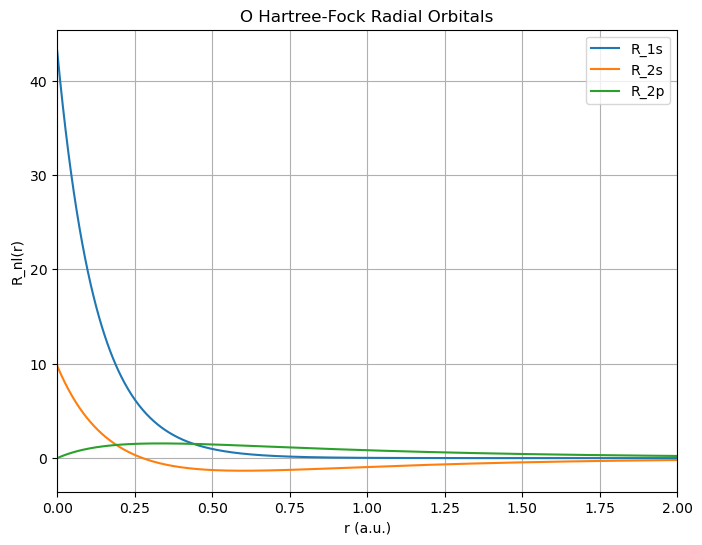

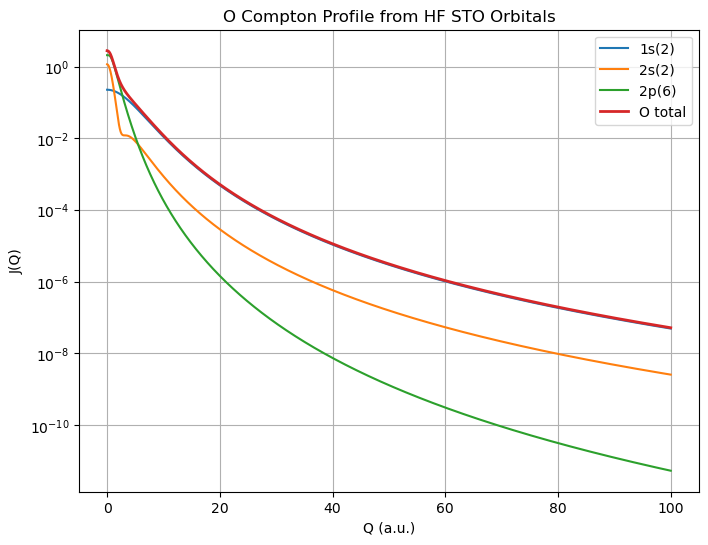

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Oxygen Hartree-Fock STO data
# O: 1s2 2s2 2p4
# Ground term: 2p
# Format: (n_j, Z_j, C_j)
# =====================================================

oxygen_1s = [
    (1, 11.2970,  0.360063),
    (1,  6.5966,  0.466625),
    (3, 20.5019, -0.000918),
    (2,  9.5546,  0.208441),
    (2,  3.2482,  0.002018),
    (2,  2.1608,  0.000216),
    (2,  1.6411,  0.000133),
]

oxygen_2s = [
    (1, 11.2970, -0.064363),
    (1,  6.5966,  0.433186),
    (3, 20.5019, -0.000275),
    (2,  9.5546, -0.072497),
    (2,  3.2482, -0.369900),
    (2,  2.1608, -0.512627),
    (2,  1.6411, -0.227421),
]

oxygen_2p = [
    (2, 9.6471, 0.005626),
    (2, 4.3323, 0.126618),
    (2, 2.7502, 0.328966),
    (2, 1.7525, 0.395422),
    (2, 1.2473, 0.231788),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, oxygen_1s)
R2s = R_nl(r, oxygen_2s)
R2p = R_nl(r, oxygen_2p)

print_R_formula(oxygen_1s, "O_R1s")
print_R_formula(oxygen_2s, "O_R2s")

print_R_formula(oxygen_2p, "O_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# O: 1s2 2s2 2p4
J_total = 2*J_1s + 2*J_2s + 4*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_O": J_total
    })
print(table)
table.to_csv("O_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("O Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_total, label="O total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("O Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()